<a href="https://colab.research.google.com/github/AxelJohnson1988/AxelJohnson1988-project/blob/main/Getting_started_with_BigQuery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Before you begin


1.   Use the [Cloud Resource Manager](https://console.cloud.google.com/cloud-resource-manager) to Create a Cloud Platform project if you do not already have one.
2.   [Enable billing](https://support.google.com/cloud/answer/6293499#enable-billing) for the project.
3.   [Enable BigQuery](https://console.cloud.google.com/flows/enableapi?apiid=bigquery) APIs for the project.


### Provide your credentials to the runtime

In [ ]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


### Declare the Cloud project ID which will be used throughout this notebook

In [ ]:
project_id = '[your project ID]'

### Optional: Enable data table display

Colab includes the ``google.colab.data_table`` package that can be used to display large pandas dataframes as an interactive data table.
It can be enabled with:

In [ ]:
%load_ext google.colab.data_table

If you would prefer to return to the classic Pandas dataframe display, you can disable this by running:
```python
%unload_ext google.colab.data_table
```

# Use BigQuery via magics

The `google.cloud.bigquery` library also includes a magic command which runs a query and either displays the result or saves it to a variable as a `DataFrame`.

In [ ]:
# Display query output immediately

%%bigquery --project {project_id}
SELECT
  COUNT(*) as total_rows
FROM `bigquery-public-data.samples.gsod`

,total_rows
0,114420316


In [ ]:
# Save output in a variable `df`

%%bigquery df --project {project_id}
SELECT
  COUNT(*) as total_rows
FROM `bigquery-public-data.samples.gsod`

In [ ]:
df

,total_rows
0,114420316


# Use BigQuery through BigQuery DataFrames

See [BigQuery documentation](https://cloud.google.com/bigquery/docs) and [BigQuery DataFrames reference documentation](https://cloud.google.com/python/docs/reference/bigframes/latest).

The [GSOD sample table](https://console.cloud.google.com/bigquery?p=bigquery-public-data&d=samples&t=gsod&page=table) contains weather information collected by NOAA, such as precipitation amounts and wind speeds from late 1929 to early 2010.


### Sample approximately 2000 random rows

In [ ]:
import bigframes.pandas as bpd

bpd.options.bigquery.project = project_id

sample_count = 2000

df = bpd.read_gbq("bigquery-public-data.samples.gsod")

row_count = df.shape[0]

df = df.sample(sample_count)

print('Full dataset has %d rows' % row_count)

Full dataset has 114420316 rows


### Describe the sampled data

In [ ]:
df.describe()

,station_number,wban_number,year,month,day,mean_temp,num_mean_temp_samples,mean_dew_point,num_mean_dew_point_samples,mean_sealevel_pressure,...,mean_visibility,num_mean_visibility_samples,mean_wind_speed,num_mean_wind_speed_samples,max_sustained_wind_speed,max_gust_wind_speed,max_temperature,min_temperature,total_precipitation,snow_depth
count,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,2000.0,1905.0,1905.0,1503.0,...,1784.0,1784.0,1977.0,1977.0,1944.0,272.0,2000.0,0.0,1819.0,103.0
mean,509229.928,91090.3395,1987.1865,6.5395,16.016,52.792,12.9165,42.083045,12.740682,1014.776314,...,12.512332,12.556614,6.718816,12.843703,12.149588,25.480882,44.03815,<NA>,0.08061,10.0
std,301968.506371,25341.066819,16.104204,3.424953,8.722717,23.463624,7.867431,22.223635,7.84855,9.095351,...,9.736078,7.797144,4.952929,7.847506,7.031532,9.874374,23.735059,<NA>,0.288874,11.402837
min,10070.0,3103.0,1936.0,1.0,1.0,-52.900002,4.0,-57.299999,4.0,959.5,...,0.0,4.0,0.0,4.0,1.0,8.0,-61.799999,<NA>,0.0,0.4
25%,236910.0,99999.0,1977.0,4.0,9.0,39.599998,7.0,29.700001,7.0,1009.400024,...,6.5,6.0,3.3,7.0,7.8,19.0,32.0,<NA>,0.0,2.4
50%,542920.0,99999.0,1989.0,6.0,16.0,55.0,8.0,43.5,8.0,1014.5,...,9.9,8.0,5.8,8.0,11.1,23.299999,46.400002,<NA>,0.0,5.9
75%,725090.0,99999.0,2001.0,10.0,23.0,70.0,23.0,57.5,23.0,1020.099976,...,15.0,23.0,8.9,23.0,15.5,29.9,60.799999,<NA>,0.01,15.0
max,999999.0,99999.0,2010.0,12.0,31.0,101.400002,24.0,81.800003,24.0,1055.699951,...,99.400002,24.0,53.5,24.0,88.0,89.0,91.0,<NA>,3.54,82.699997


### View arbitrary 10 rows

In [ ]:
df.peek(10)

,station_number,wban_number,year,month,day,mean_temp,num_mean_temp_samples,mean_dew_point,num_mean_dew_point_samples,mean_sealevel_pressure,...,min_temperature,min_temperature_explicit,total_precipitation,snow_depth,fog,rain,snow,hail,thunder,tornado
35349954,638870,99999,1961,6,8,68.599998,5,47.0,5,<NA>,...,<NA>,<NA>,0.0,<NA>,False,False,False,False,False,False
2497913,543370,99999,1982,3,27,38.400002,8,28.799999,8,1026.099976,...,<NA>,<NA>,0.04,<NA>,False,False,False,False,False,False
46805715,38660,99999,1989,9,14,58.799999,22,54.0,22,<NA>,...,<NA>,<NA>,<NA>,<NA>,False,False,False,False,False,False
45388121,713970,99999,1984,7,31,69.300003,24,57.099998,24,1017.900024,...,<NA>,<NA>,0.0,<NA>,False,False,False,False,False,False
105768579,287040,99999,1969,11,1,32.0,8,29.4,8,1002.700012,...,<NA>,<NA>,0.0,<NA>,False,False,False,False,False,False
49492447,10250,99999,1996,8,18,51.200001,24,47.400002,24,1010.900024,...,<NA>,<NA>,0.12,<NA>,False,False,False,False,False,False
45658252,161150,99999,1994,7,14,75.800003,13,70.400002,13,<NA>,...,<NA>,<NA>,0.0,<NA>,False,False,False,False,False,False
99477822,281310,99999,1981,11,8,30.200001,7,25.1,6,1020.5,...,<NA>,<NA>,0.0,<NA>,False,False,False,False,False,False
77950004,722926,3154,1996,12,8,57.5,24,44.200001,21,1019.200012,...,<NA>,<NA>,0.0,<NA>,False,False,False,False,False,False
99829908,107710,99999,2002,7,28,69.699997,16,55.200001,16,1020.700012,...,<NA>,<NA>,0.0,<NA>,False,False,False,False,False,False


### View 10 highest total_precipitation samples

In [ ]:
df.sort_values('total_precipitation', ascending=False).head(10)[['station_number', 'year', 'month', 'day', 'total_precipitation']]

,station_number,year,month,day,total_precipitation
48210163,722140,1976,11,28,3.54
100473809,322460,1961,3,26,2.95
96170642,972600,1979,3,1,2.76
61880958,476550,1961,4,26,2.72
43527842,619740,1983,10,16,2.6
34344262,964210,1996,4,29,2.56
43236540,483280,1986,5,23,2.52
114338091,851230,2005,3,19,2.44
104373932,82150,1989,11,20,2.36
35250392,471065,1975,7,24,2.36


# Use BigQuery through google-cloud-bigquery

See [BigQuery documentation](https://cloud.google.com/bigquery/docs) and [library reference documentation](https://googlecloudplatform.github.io/google-cloud-python/latest/bigquery/usage.html).

The [GSOD sample table](https://console.cloud.google.com/bigquery?p=bigquery-public-data&d=samples&t=gsod&page=table) contains weather information collected by NOAA, such as precipitation amounts and wind speeds from late 1929 to early 2010.


### Sample approximately 2000 random rows

In [ ]:
from google.cloud import bigquery

client = bigquery.Client(project=project_id)

sample_count = 2000
row_count = client.query('''
  SELECT
    COUNT(*) as total
  FROM `bigquery-public-data.samples.gsod`''').to_dataframe().total[0]

df = client.query('''
  SELECT
    *
  FROM
    `bigquery-public-data.samples.gsod`
  WHERE RAND() < %d/%d
''' % (sample_count, row_count)).to_dataframe()

print('Full dataset has %d rows' % row_count)

Full dataset has 114420316 rows


### Describe the sampled data

In [ ]:
df.describe()

,station_number,wban_number,year,month,day,mean_temp,num_mean_temp_samples,mean_dew_point,num_mean_dew_point_samples,mean_sealevel_pressure,...,mean_visibility,num_mean_visibility_samples,mean_wind_speed,num_mean_wind_speed_samples,max_sustained_wind_speed,max_gust_wind_speed,max_temperature,min_temperature,total_precipitation,snow_depth
count,1917.0,1917.0,1917.0,1917.0,1917.0,1917.000000,1917.0,1837.000000,1837.0,1428.000000,...,1723.000000,1723.0,1894.000000,1894.0,1858.000000,258.000000,1915.000000,0.0,1745.000000,108.000000
mean,502447.478352,89822.252478,1986.604591,6.489828,15.766823,51.783516,13.098592,41.707730,13.045727,1014.851050,...,11.872838,12.859547,6.969799,13.047518,12.337675,24.364341,43.315718,NaN,0.068115,9.568518
std,299118.262175,27008.869915,16.451458,3.453014,8.841116,24.125164,7.974397,22.294639,7.981465,9.420865,...,9.545982,7.936962,4.987575,7.953833,6.642102,9.405444,24.079599,NaN,0.264338,8.773491
min,10015.0,6.0,1932.0,1.0,1.0,-88.599998,4.0,-64.500000,4.0,966.000000,...,0.000000,4.0,0.000000,4.0,1.000000,5.800000,-94.500000,NaN,0.000000,0.400000
25%,235270.0,99999.0,1977.0,3.0,8.0,37.000000,7.0,28.900000,7.0,1009.599976,...,6.300000,7.0,3.500000,7.0,7.800000,18.100000,30.200001,NaN,0.000000,2.000000
50%,532760.0,99999.0,1989.0,6.0,16.0,54.500000,8.0,44.099998,8.0,1014.599976,...,9.300000,8.0,6.000000,8.0,11.700000,22.900000,46.000000,NaN,0.000000,6.700000
75%,724555.0,99999.0,2000.0,10.0,24.0,70.199997,24.0,57.299999,23.0,1020.099976,...,14.600000,23.0,9.200000,23.0,15.500000,28.000000,60.299999,NaN,0.010000,13.400000
max,999999.0,99999.0,2010.0,12.0,31.0,98.500000,24.0,79.800003,24.0,1059.800049,...,99.400002,24.0,46.400002,24.0,68.000000,62.200001,91.599998,NaN,4.530000,34.599998


### View the first 10 rows

In [ ]:
df.head(10)

,station_number,wban_number,year,month,day,mean_temp,num_mean_temp_samples,mean_dew_point,num_mean_dew_point_samples,mean_sealevel_pressure,...,min_temperature,min_temperature_explicit,total_precipitation,snow_depth,fog,rain,snow,hail,thunder,tornado
0,942030,99999,1948,2,15,81.000000,7,76.900002,7,NaN,...,NaN,<NA>,0.01,NaN,False,False,False,False,False,False
1,722580,13960,1953,8,14,86.800003,24,70.800003,24,1016.799988,...,NaN,<NA>,0.00,NaN,False,False,False,False,False,False
2,725430,94822,1975,5,12,55.400002,24,42.200001,24,1013.200012,...,NaN,<NA>,0.04,NaN,False,False,False,False,False,False
3,299150,99999,1979,8,31,71.900002,6,52.099998,6,1017.200012,...,NaN,<NA>,0.00,NaN,False,False,False,False,False,False
4,310040,99999,1986,12,27,-37.299999,6,-43.500000,6,1047.500000,...,NaN,<NA>,0.04,NaN,False,False,False,False,False,False
5,370470,99999,1987,10,14,50.099998,6,45.599998,6,1023.900024,...,NaN,<NA>,0.00,NaN,False,False,False,False,False,False
6,725127,4726,1989,1,6,25.299999,18,22.100000,18,NaN,...,NaN,<NA>,0.00,NaN,True,True,True,True,True,True
7,684380,99999,1994,7,1,38.599998,6,20.799999,6,NaN,...,NaN,<NA>,0.00,NaN,False,False,False,False,False,False
8,443020,99999,1994,12,11,0.100000,7,-3.100000,7,1033.599976,...,NaN,<NA>,0.00,1.6,False,False,False,False,False,False
9,110320,99999,1994,12,11,45.599998,8,43.799999,8,1026.000000,...,NaN,<NA>,0.35,NaN,False,False,False,False,False,False


In [ ]:
# 10 highest total_precipitation samples
df.sort_values('total_precipitation', ascending=False).head(10)[['station_number', 'year', 'month', 'day', 'total_precipitation']]

,station_number,year,month,day,total_precipitation
632,594930,1992,6,13,4.53
1139,973720,2008,2,9,3.78
193,209630,1987,10,18,3.50
1445,232050,1969,3,31,2.76
1235,216360,1973,9,27,2.17
1755,478970,1999,6,19,2.17
1831,986180,1996,10,8,2.13
1018,321660,1984,9,10,1.57
176,478070,1963,8,28,1.57
725,73740,1988,10,3,1.54


# Use BigQuery through pandas-gbq

The `pandas-gbq` library is a community led project by the pandas community. It covers basic functionality, such as writing a DataFrame to BigQuery and running a query, but as a third-party library it may not handle all BigQuery features or use cases.

[Pandas GBQ Documentation](https://googleapis.dev/python/pandas-gbq/latest/index.html)

In [ ]:
import pandas_gbq

df = pandas_gbq.read_gbq('''
  SELECT name, SUM(number) as count
  FROM `bigquery-public-data.usa_names.usa_1910_2013`
  WHERE state = 'TX'
  GROUP BY name
  ORDER BY count DESC
  LIMIT 100;
''', project_id=project_id, dialect='standard', progress_bar_type=None)

df.head()

,name,count
0,James,272793
1,John,235139
2,Michael,225320
3,Robert,220399
4,David,219028


# Syntax highlighting
`google.colab.syntax` can be used to add syntax highlighting to any Python string literals which are used in a query later.

In [ ]:
from google.colab import syntax

query = syntax.sql('''
SELECT
  COUNT(*) as total_rows
FROM
  `bigquery-public-data.samples.gsod`;
''')

pandas_gbq.read_gbq(
    query,
    project_id=project_id, dialect='standard', progress_bar_type=None)

,total_rows
0,114420316


In [83]:
display(miami_df.head())

,name,phones,street,city,state,zipcode,categories,email,website,working_hours,payment_methods,extraction_date,original_listing_url
0,EZ Plumbing Septic Tanks,(786) 306-7781,14001 NW 2nd Ave,Miami,FL,33168,Plumbers,NaN,https://septicservicesmiami.com,Mon - Sat: 6:00 am - 10:00 pm,NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/ez-pl...
1,Excellent Plumbing,(786) 970-9702,15755 SW 148th Street Rd,Miami,FL,33186,"Plumbers, Water Heater Repair",NaN,http://excellentplumbingfl.localsearch.com,NaN,NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/excel...
2,Andy's Plumbing,"(645) 202-7309, (786) 632-5531",10201 Hammocks Blvd,Miami,FL,33196,Plumbers,NaN,https://voxservices.net,"Mon - Sun: 6:00 am - 12:00 am, Mon - Sun: 6:00...",NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/andys...
3,AJP Plumbing,(305) 906-2457,NaN,Miami,FL,33155,"Heating Contractors & Specialties, Plumbers",NaN,https://go.thryv.com/site/gth89fgkz1hgcqg8,"Mon - Sun: Open 24 Hours, Mon - Sun: Open 24 H...",NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/ajp-p...
4,Goldstar Plumbing,(305) 894-9917,2280 NW 20th St,Miami,FL,33142,Plumbers,NaN,http://goldstarplumbing545194997.localsearch.com,NaN,NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/golds...


In [84]:
print(miami_df.isnull().sum())

name                     0
phones                   0
street                   4
city                     0
state                    0
zipcode                  0
categories               0
email                   22
website                  0
working_hours            8
payment_methods         21
extraction_date          0
original_listing_url     0
dtype: int64


In [85]:
miami_df['street'].fillna('Unknown Street', inplace=True)

In [86]:
print(miami_df['street'].isnull().sum())

0


In [87]:
miami_df['working_hours'] = miami_df['working_hours'].str.split(',').str[0].str.strip()

In [88]:
display(miami_df.head())

,name,phones,street,city,state,zipcode,categories,email,website,working_hours,payment_methods,extraction_date,original_listing_url
0,EZ Plumbing Septic Tanks,(786) 306-7781,14001 NW 2nd Ave,Miami,FL,33168,Plumbers,NaN,https://septicservicesmiami.com,Mon - Sat: 6:00 am - 10:00 pm,NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/ez-pl...
1,Excellent Plumbing,(786) 970-9702,15755 SW 148th Street Rd,Miami,FL,33186,"Plumbers, Water Heater Repair",NaN,http://excellentplumbingfl.localsearch.com,NaN,NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/excel...
2,Andy's Plumbing,"(645) 202-7309, (786) 632-5531",10201 Hammocks Blvd,Miami,FL,33196,Plumbers,NaN,https://voxservices.net,Mon - Sun: 6:00 am - 12:00 am,NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/andys...
3,AJP Plumbing,(305) 906-2457,Unknown Street,Miami,FL,33155,"Heating Contractors & Specialties, Plumbers",NaN,https://go.thryv.com/site/gth89fgkz1hgcqg8,Mon - Sun: Open 24 Hours,NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/ajp-p...
4,Goldstar Plumbing,(305) 894-9917,2280 NW 20th St,Miami,FL,33142,Plumbers,NaN,http://goldstarplumbing545194997.localsearch.com,NaN,NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/golds...


In [89]:
miami_df['categories'] = miami_df['categories'].str.split(',').str[0].str.strip()

In [90]:
display(miami_df.head())

,name,phones,street,city,state,zipcode,categories,email,website,working_hours,payment_methods,extraction_date,original_listing_url
0,EZ Plumbing Septic Tanks,(786) 306-7781,14001 NW 2nd Ave,Miami,FL,33168,Plumbers,NaN,https://septicservicesmiami.com,Mon - Sat: 6:00 am - 10:00 pm,NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/ez-pl...
1,Excellent Plumbing,(786) 970-9702,15755 SW 148th Street Rd,Miami,FL,33186,Plumbers,NaN,http://excellentplumbingfl.localsearch.com,NaN,NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/excel...
2,Andy's Plumbing,"(645) 202-7309, (786) 632-5531",10201 Hammocks Blvd,Miami,FL,33196,Plumbers,NaN,https://voxservices.net,Mon - Sun: 6:00 am - 12:00 am,NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/andys...
3,AJP Plumbing,(305) 906-2457,Unknown Street,Miami,FL,33155,Heating Contractors & Specialties,NaN,https://go.thryv.com/site/gth89fgkz1hgcqg8,Mon - Sun: Open 24 Hours,NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/ajp-p...
4,Goldstar Plumbing,(305) 894-9917,2280 NW 20th St,Miami,FL,33142,Plumbers,NaN,http://goldstarplumbing545194997.localsearch.com,NaN,NaN,2025-12-15,https://www.yellowpages.com/miami-fl/mip/golds...


In [91]:
miami_df['email'].fillna('Not Available', inplace=True)
miami_df['payment_methods'].fillna('Not Available', inplace=True)

In [92]:
print(miami_df.isnull().sum())

name                    0
phones                  0
street                  0
city                    0
state                   0
zipcode                 0
categories              0
email                   0
website                 0
working_hours           8
payment_methods         0
extraction_date         0
original_listing_url    0
dtype: int64


In [95]:
print(miami_df['categories'].value_counts())

categories
Plumbers                             26
Heating Contractors & Specialties     1
Air Conditioning Service & Repair     1
Home Improvements                     1
Building Contractors                  1
Name: count, dtype: int64


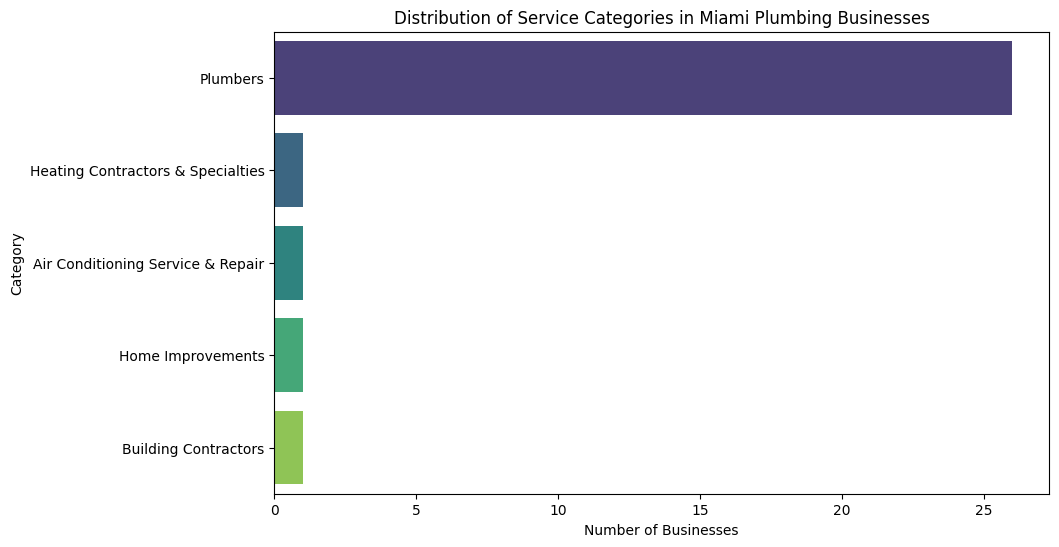

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=miami_df, y='categories', order=miami_df['categories'].value_counts().index, palette='viridis')
plt.title('Distribution of Service Categories in Miami Plumbing Businesses')
plt.xlabel('Number of Businesses')
plt.ylabel('Category')
plt.show()

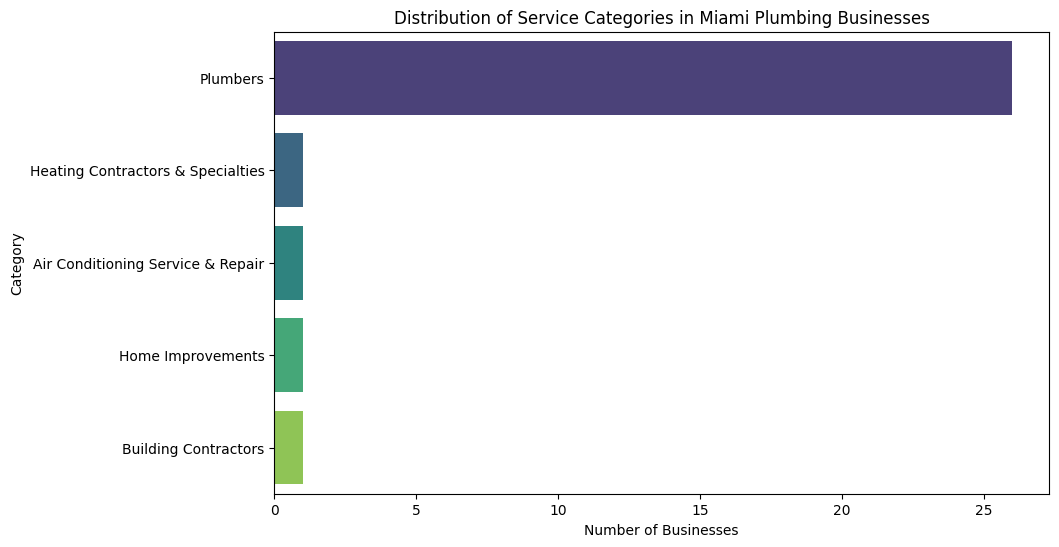

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=miami_df, y='categories', order=miami_df['categories'].value_counts().index, palette='viridis')
plt.title('Distribution of Service Categories in Miami Plumbing Businesses')
plt.xlabel('Number of Businesses')
plt.ylabel('Category')
plt.show()

In [93]:
miami_df['working_hours'].fillna('Not Available', inplace=True)

In [94]:
print(miami_df.isnull().sum())

name                    0
phones                  0
street                  0
city                    0
state                   0
zipcode                 0
categories              0
email                   0
website                 0
working_hours           0
payment_methods         0
extraction_date         0
original_listing_url    0
dtype: int64


### Key Performance Metrics from `job_tracker_df`

In [100]:
import kagglehub
path = kagglehub.dataset_download("mirzahasnine/loan-data-set")

100%|██████████| 10.9k/10.9k [00:00<00:00, 6.86MB/s]

Extracting files...


In [101]:
import kagglehub
path = kagglehub.dataset_download("thuynyle/redfin-housing-market-data")

100%|██████████| 2.77G/2.77G [00:45<00:00, 65.6MB/s]

Extracting files...


In [102]:
import kagglehub
path = kagglehub.dataset_download("sunil123kumar/ai-agent-failure-benchmark-dataset")

100%|██████████| 104k/104k [00:00<00:00, 25.6MB/s]

Extracting files...


In [103]:
import kagglehub
path = kagglehub.dataset_download("haroldg/time-series-of-transactions-money-laundering")

100%|██████████| 884M/884M [00:08<00:00, 106MB/s]

Extracting files...


In [104]:
import kagglehub
path = kagglehub.dataset_download("thedevastator/rental-affordability-analysis-based-on-median-in")

100%|██████████| 37.4k/37.4k [00:00<00:00, 31.9MB/s]

Extracting files...


In [105]:
import kagglehub
path = kagglehub.dataset_download("rudrakumargupta/banking-faq-dataset-for-chatbot-training")

100%|██████████| 62.1k/62.1k [00:00<00:00, 32.9MB/s]

Extracting files...


## Analyzing Kaggle Datasets for Business Insights

Let's start by exploring the `loan-data-set`.

In [107]:
import kagglehub
path = kagglehub.dataset_download("alfiegrace/linkedin-freelancer-survey-results")

100%|██████████| 679/679 [00:00<00:00, 557kB/s]

Extracting files...


In [108]:
import kagglehub
path = kagglehub.dataset_download("willianoliveiragibin/start-a-business-2003-to-2019")

100%|██████████| 14.0k/14.0k [00:00<00:00, 9.87MB/s]

Extracting files...


In [110]:
import kagglehub
path = kagglehub.model_download('oxzaid10/gemma-4-31b-financial-reasoning-lora/pyTorch/lora-r16-financial-qa/1')


100%|██████████| 790/790 [00:00<00:00, 149kB/s]



100%|██████████| 8.64k/8.64k [00:00<00:00, 13.6MB/s]



100%|██████████| 6.19k/6.19k [00:00<00:00, 19.6MB/s]



  0%|          | 0.00/83.6M [00:00<?, ?B/s]



100%|██████████| 16.1k/16.1k [00:00<00:00, 17.7MB/s]




100%|██████████| 50.9k/50.9k [00:00<00:00, 33.3MB/s]




100%|██████████| 695/695 [00:00<00:00, 231kB/s]




100%|██████████| 4.13k/4.13k [00:00<00:00, 4.78MB/s]

  1%|          | 1.00M/83.6M [00:00<00:25, 3.36MB/s]
  5%|▍         | 4.00M/83.6M [00:00<00:07, 11.6MB/s]
 13%|█▎        | 11.0M/83.6M [00:00<00:02, 30.1MB/s]
 22%|██▏       | 18.0M/83.6M [00:00<00:01, 42.1MB/s]
 29%|██▊       | 24.0M/83.6M [00:00<00:01, 43.5MB/s]
 38%|███▊      | 32.0M/83.6M [00:00<00:01, 50.7MB/s]



  0%|          | 0.00/30.7M [00:00<?, ?B/s]
 47%|████▋     | 39.0M/83.6M [00:01<00:02, 19.9MB/s]

 88%|████████▊ | 27.0M/30.7M [00:00<00:00, 275MB/s]
100%|██████████| 30.7M/30.7M [00:00<00:00, 252MB/s]

 69%|██████▉   | 58.0M/83.6M [00:01<00:00, 36.8MB/s]
 78%|███████▊  | 65.0M/83.6M [00:02<00:00, 42.6MB/s]
 86%|████████▌ | 72.0M/83.6M [00:02<00:00, 42.5MB/s]
100%|██████████| 83.6M/83.6M [00:02<00:00, 37.0MB/s]


In [111]:
import kagglehub
path = kagglehub.dataset_download("thedevastator/ai-based-job-site-matching")

100%|██████████| 1.86M/1.86M [00:00<00:00, 109MB/s]

Extracting files...


In [106]:
import pandas as pd
import os

# Assuming the 'path' variable from the previous kagglehub.dataset_download call points to the loan-data-set
# The path should be something like '/root/.cache/kagglehub/datasets/mirzahasnine/loan-data-set/versions/1'
# Let's find the actual CSV file within that directory.

loan_dataset_dir = '/root/.cache/kagglehub/datasets/mirzahasnine/loan-data-set/versions/1'
csv_files_in_loan_dataset = [f for f in os.listdir(loan_dataset_dir) if f.endswith('.csv')]

if csv_files_in_loan_dataset:
    loan_csv_path = os.path.join(loan_dataset_dir, csv_files_in_loan_dataset[0])
    loan_df = pd.read_csv(loan_csv_path)
    print(f"Loaded dataset from: {loan_csv_path}")
    print("First 5 rows of loan_df:")
    display(loan_df.head())
else:
    print(f"No CSV files found in {loan_dataset_dir}")

Loaded dataset from: /root/.cache/kagglehub/datasets/mirzahasnine/loan-data-set/versions/1/loan_test.csv
First 5 rows of loan_df:


,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Term,Credit_History,Area
0,Male,Yes,0,Graduate,No,572000,0,11000000,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,307600,150000,12600000,360.0,1.0,Urban
2,Male,Yes,2,Graduate,No,500000,180000,20800000,360.0,1.0,Urban
3,Male,Yes,2,Graduate,No,234000,254600,10000000,360.0,NaN,Urban
4,Male,No,0,Not Graduate,No,327600,0,7800000,360.0,1.0,Urban


In [109]:
# Select only numerical columns for correlation analysis
numerical_cols = loan_df.select_dtypes(include=['number']).columns

# Calculate the correlation matrix for numerical columns
correlation_matrix = loan_df[numerical_cols].corr()

# Display correlations with 'Loan_Amount'
print("Correlation with Loan_Amount:")
display(correlation_matrix['Loan_Amount'].sort_values(ascending=False))

Correlation with Loan_Amount:


,Loan_Amount
Loan_Amount,1.000000
Applicant_Income,0.458769
Coapplicant_Income,0.144788
Term,0.072222
Credit_History,-0.009757


In [98]:
print('--- Job Performance Metrics ---')
print(f"Total Number of Jobs: {job_tracker_df.shape[0]}")
print(f"Average Total Charged per Job: ${job_tracker_df['Total_Charged'].mean():.2f}")
print(f"Average Materials Cost per Job: ${job_tracker_df['Materials_Cost'].mean():.2f}")
print(f"Average Net Profit per Job: ${job_tracker_df['Net_Profit'].mean():.2f}")

--- Job Performance Metrics ---
Total Number of Jobs: 3
Average Total Charged per Job: $270.00
Average Materials Cost per Job: $56.83
Average Net Profit per Job: $213.17


In [99]:
job_tracker_df['Profit_Margin_Percentage'] = (job_tracker_df['Net_Profit'] / job_tracker_df['Total_Charged']) * 100
display(job_tracker_df)

,Date,Client_Name,Location,Job_Type,Description,Total_Charged,Materials_Cost,Net_Profit,Profit_Margin_Percentage
0,2026-09-08,John Doe,Edina - 50th & France,Plumbing,Fixed leaky sink trap & replaced washer,250.0,35.5,214.5,85.800000
1,2026-09-08,Sarah Smith,Edina - Centennial Lakes,Yard Work,Spring cleanup and mulch spreading,380.0,120.0,260.0,68.421053
2,2026-09-08,Mike Johnson,Edina - Pamela Park,General,Mounted 2 TVs and hung shelves,180.0,15.0,165.0,91.666667


## Overview of Kaggle Datasets for Edina Handyman Business Insights

To gain insights for your new handyman business in Edina, we can draw valuable information from several of the Kaggle datasets that have been downloaded, as well as the `job_tracker_df` and `miami_df` already in memory. While a single 'mass dataset' combining all these disparate sources directly might be challenging due to varying granularities and topics, we can extract key metrics and integrate these insights conceptually.

### Relevant Datasets and Potential Insights:

1.  **`loan_df` (from `mirzahasnine/loan-data-set`)**
    *   **Overview:** Contains loan application details, including applicant income and loan amounts.
    *   **Useful Metrics:**
        *   `Applicant_Income`: Can indicate the general financial capacity of potential customers to afford home improvement services.
        *   `Loan_Amount`: Might correlate with the scale of home renovation or repair projects customers are undertaking.
    *   **Insight:** Helps understand the financial demographic of potential clients and their ability to invest in home services.

2.  **`redfin-housing-market-data` (from `thuynyle/redfin-housing-market-data`)**
    *   **Overview:** Likely provides data on housing sales, prices, and market trends.
    *   **Useful Metrics:**
        *   `Median_Home_Price`: Higher property values often correspond to homeowners willing to spend more on maintenance and upgrades.
        *   `Home_Sales_Volume` / `Days_on_Market`: High turnover in the housing market often generates demand for handyman services (e.g., repairs for selling, renovations for moving in).
    *   **Insight:** Identifies periods of high demand for home services and potential high-value neighborhoods in Edina (if localized data is available).

3.  **`rental-affordability-analysis-based-on-median-in` (from `thedevastator/rental-affordability-analysis-based-on-median-in`)**
    *   **Overview:** Focuses on rental prices and median income for affordability analysis.
    *   **Useful Metrics:**
        *   `Rental_Prices`: Can indicate areas with significant rental properties, whose landlords are often clients for maintenance and repair services.
        *   `Median_Income`: Helps in understanding the general economic status of renters and potential pricing strategies for services tailored to rental properties.
    *   **Insight:** Helps target landlords as a client segment and informs pricing for different income brackets.

4.  **`linkedin-freelancer-survey-results` (from `alfiegrace/linkedin-freelancer-survey-results`)**
    *   **Overview:** Survey data on the freelance market, including income, services, and challenges.
    *   **Useful Metrics:**
        *   `Freelancer_Income`: Provides benchmarks for what other independent service providers charge.
        *   `Services_Offered`: Can reveal common freelance services, possibly including handyman-like tasks, indicating competition or collaboration opportunities.
    *   **Insight:** Offers competitive intelligence and informs on potential labor costs if you plan to hire freelancers or expand your team.

5.  **`start-a-business-2003-to-2019` (from `willianoliveiragibin/start-a-business-2003-to-2019`)**
    *   **Overview:** Historical data on new business formations.
    *   **Useful Metrics:**
        *   `New_Business_Formations_by_Industry/Location`: Can help gauge overall economic activity and the density of new service businesses, informing market entry strategies.
    *   **Insight:** Provides a macro view of entrepreneurial activity and potential market saturation or growth areas.

6.  **`ai-based-job-site-matching` (from `thedevastator/ai-based-job-site-matching`)**
    *   **Overview:** Data related to job requirements and worker skills for matching.
    *   **Useful Metrics:**
        *   `Required_Skills_for_Handyman_Jobs`: Can identify in-demand skills in the local labor market.
        *   `Common_Job_Types`: Further validates service offerings based on labor market needs.
    *   **Insight:** Useful for understanding the labor supply if you plan to hire, and what skills are prevalent or in demand for service provision.

7.  **`job_tracker_df` (already in memory)**
    *   **Overview:** Your actual handyman job tracking data with detailed financial metrics.
    *   **Useful Metrics:**
        *   `Job_Type`: Direct insight into what services you are currently performing and their frequency.
        *   `Total_Charged`, `Net_Profit`, `Profit_Margin_Percentage`: Crucial for setting pricing and evaluating the profitability of different job types.
    *   **Insight:** Provides direct, actionable data for optimizing your service offerings and pricing strategy based on your own business performance.

8.  **`miami_df` (already in memory)**
    *   **Overview:** Miami plumbing services data, including service categories and working hours.
    *   **Useful Metrics:**
        *   `categories`: Can suggest a broader range of related services that a handyman business could offer beyond core tasks.
        *   `working_hours`: Provides context on operational patterns of similar businesses.
    *   **Insight:** Expands thinking on service diversification and operational considerations, though it's important to remember this is specific to Miami plumbing.

### Combining Insights into a "Mass Dataset" (Conceptual Integration)

Instead of a single, massive, joined DataFrame, a more effective approach would be to create an **integrated analytical framework or dashboard**. This would involve:

*   **Geographic Segmentation:** Aggregating relevant housing and demographic data (from Redfin and Rental Affordability datasets) to understand market characteristics and demand within Edina, potentially identifying specific neighborhoods with high potential.
*   **Service Demand & Profitability Analysis:** Combining your `job_tracker_df` (for actual performance) with insights from `miami_df` categories and `linkedin-freelancer-survey-results` (for market offerings and pricing) to identify profitable service niches and optimize your service portfolio.
*   **Client Profiling:** Using `loan_df` insights on income and `rental-affordability-analysis-based-on-median-in` on median income to develop profiles of ideal customer segments (e.g., homeowners with disposable income for upgrades, landlords needing regular maintenance).
*   **Competitive & Labor Landscape:** Summarizing insights from `linkedin-freelancer-survey-results`, `start-a-business-2003-to-2019`, and `ai-based-job-site-matching` to understand competitor offerings, potential market saturation, and the availability of skilled labor if you scale.

This integrated view would allow you to make informed decisions on market positioning, service offerings, pricing strategies, and growth plans for your Edina handyman business.

In [113]:
import os
import pandas as pd
import kagglehub

redfin_dataset_dir = kagglehub.dataset_download("thuynyle/redfin-housing-market-data")
redfin_data_path = None

# Recursively search for a TSV file within the dataset directory
for root, dirs, files in os.walk(redfin_dataset_dir):
    for file in files:
        if file.endswith('.tsv000'):
            redfin_data_path = os.path.join(root, file)
            print(f"Found Redfin file: {redfin_data_path}")
            break
    if redfin_data_path:
        break

if redfin_data_path:
    try:
        # Due to the large size of the Redfin dataset, we will only load a small sample for inspection
        redfin_df_sample = pd.read_csv(redfin_data_path, sep='\t', nrows=10000)
        print("Successfully loaded a sample of Redfin data.")
        display(redfin_df_sample.head())
        print("Redfin DataFrame columns:")
        print(redfin_df_sample.columns.tolist())
        redfin_df = redfin_df_sample # Assign sample to redfin_df for initial analysis
    except Exception as e:
        print(f"Error loading Redfin data: {e}")
        print("Attempting to read with a different encoding or engine if necessary.")
else:
    print(f"No TSV files found within {redfin_dataset_dir} or its subdirectories.")

No CSV files found within /root/.cache/kagglehub/datasets/thuynyle/redfin-housing-market-data/versions/4 or its subdirectories.


In [114]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("thedevastator/ai-based-job-site-matching")
print("Path to dataset files:", path)

# Find and load the CSV
job_matching_csv = None
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith('.csv'):
            job_matching_csv = os.path.join(root, file)
            break
    if job_matching_csv:
        break

if job_matching_csv:
    job_matching_df = pd.read_csv(job_matching_csv)
    print(f"\nSuccessfully loaded: {job_matching_csv}")
    display(job_matching_df.head())
    print("\nColumns in dataset:", job_matching_df.columns.tolist())
else:
    print("\nNo CSV found in the dataset directory.")

Path to dataset files: /root/.cache/kagglehub/datasets/thedevastator/ai-based-job-site-matching/versions/2

Successfully loaded: /root/.cache/kagglehub/datasets/thedevastator/ai-based-job-site-matching/versions/2/dataset_time_series_analysis.csv


,Unnamed: 0,LastUpdate,GLIDEIN_Site,TotalCpus,TotalMemory,TotalDisk,ydate,mdate,hdate
0,1,2022-06-15 17:11:53,TACC-Frontera,56,192000,149506024,2022-06-15,2022-06-15 17:11:00,2022-06-15 17:00:00
1,2,2022-05-26 09:45:25,FermiGrid,56,127797,3496669764,2022-05-26,2022-05-26 09:45:00,2022-05-26 09:00:00
2,3,2022-06-17 22:00:08,CERN,8,20240,1283628100,2022-06-17,2022-06-17 22:00:00,2022-06-17 22:00:00
3,4,2022-06-10 13:14:14,FermiGrid,16,127882,312161468,2022-06-10,2022-06-10 13:14:00,2022-06-10 13:00:00
4,5,2022-06-18 10:57:47,Lancaster,8,24576,1752512504,2022-06-18,2022-06-18 10:57:00,2022-06-18 10:00:00



Columns in dataset: ['Unnamed: 0', 'LastUpdate', 'GLIDEIN_Site', 'TotalCpus', 'TotalMemory', 'TotalDisk', 'ydate', 'mdate', 'hdate']
